# Progetto Introduzione alla Data Science e al pensiero computazionale a.a. 2025-26 - Gruppo 8

Il Gruppo 8 è composto da:
*   **Gaia Gasparini:** matricola n. 1226091, gaia.gasparini@studio.unibo.it
*   **Aurora Paolicchi:** matricola n. 1216261, aurora.paolicchi@studio.unibo.it
*   **Lucrezia Volpato:** matricola n. 1231337, lucrezia.volpato@studio.unibo.it







## **Customer Churn Prediction**

**Obiettivo:** prevedere se un cliente abbandonerà il servizio (churn) sulla base
di informazioni demografiche, contrattuali e di utilizzo del servizio.

**Dataset:** Telco Customer Churn — 7.043 osservazioni, 21 variabili, target: `Churn` (Yes/No)

**Fasi del progetto**:
*   Fase 1: Descrizione e comprensione del dataset
*   Fase 2: Analisi esplorativa e visualizzazione
*   Fase 3: Modellazione
*   Fase 4: Valutazione e interpretazione dei risultati

# Preparazione ambiente

Prima di iniziare dobbiamo preparare l'ambiente Colab importando **Pandas**, **Seaborn** e **Scikit-learn**, le librerie Python che abbiamo visto in questo corso.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Carichiamo il dataset

In [37]:
from pandas.core.frame import DataFrame
# Carica il dataset
df = pd.read_csv('sample_data/Customer_Churn.csv')

# Mostra le prime 5 righe per verificare che sia tutto ok
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Fase 1: Descrizione e comprensione del dataset

## D1: Quante osservazioni e variabili contiene il dataset?



In [38]:
# Dimensioni del dataset: numero di osservazioni e variabili
print("Dimensioni del dataset:", df.shape)
print("Il numero di osservazioni del Dataset è:", df.shape[0])
print("Il numero di variabili del Dataset è:", df.shape[1])

Dimensioni del dataset: (7043, 21)
Il numero di osservazioni del Dataset è: 7043
Il numero di variabili del Dataset è: 21


Il dataset è composto da 7.043 osservazioni e 21 variabili.

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Il dataset è composto da 21 variabili: 3 numeriche (`tenure`, `MonthlyCharges`) e 18 categoriche, inclusa la variabile target `Churn`.
* `SeniorCitizen`, pur essendo codificata come intero (0/1), è di natura categorica.
* `TotalCharges`, pur rappresentando un importo monetario, è codificata come stringa — entrambe le anomalie saranno corrette in fase di preprocessing.

## D2: Esistono valori mancati o Id cliente duplicati?

In [40]:
# Verifica Id duplicati
id_duplicati = df.duplicated(subset=["customerID"]).sum()
print("Ci sono", id_duplicati, "id duplicati.")

Ci sono 0 id duplicati.


In [41]:
# Verifica valori mancanti espliciti (NaN)
print("Valori NaN per colonna:")
print(df.isnull().sum())


Valori NaN per colonna:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [42]:
# Valori vuoti nascosti in TotalCharges
print("\nValori vuoti in TotalCharges:", (df['TotalCharges'].str.strip() == '').sum())
print(df[df['TotalCharges'].str.strip() == ''][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])


Valori vuoti in TotalCharges: 11
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
3331  7644-OMVMY       0           19.85             
3826  3213-VVOLG       0           25.35             
4380  2520-SGTTA       0           20.00             
5218  2923-ARZLG       0           19.70             
6670  4075-WKNIU       0           73.35             
6754  2775-SEFEE       0           61.90             


Non sono presenti `customerID` duplicati.

Il dataset non contiene valori NaN espliciti, tuttavia `TotalCharges` nasconde 11 valori vuoti (" ") non rilevabili con `isnull()`. Tutti e 11 i casi corrispondono a clienti con `tenure = 0`, probabilmente appena acquisiti e senza addebiti registrati.

## D3: Qual è la distribuzione percentuale della variabile churn?



In [43]:
# Distribuzione della variabile target Churn
churn_percentuale = df['Churn'].value_counts(normalize=True) * 100
print(churn_percentuale.round(2))

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


Il dataset presenta un **class imbalance** moderato: il 73.46% dei clienti non ha abbandonato il servizio contro il 26.54% che lo ha fatto (~3:1). Questo squilibrio richiede attenzione nella scelta delle metriche e dell'algoritmo di classificazione.

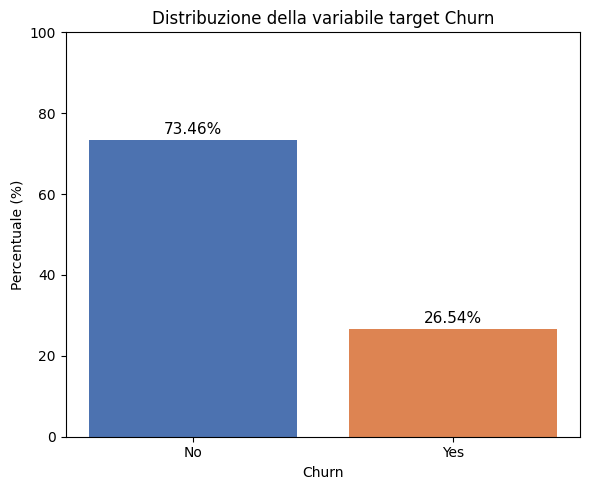

In [44]:
# Grafico a barre per visualizzare lo squilibrio delle classi
plt.figure(figsize=(6,5))
colori = ['#4C72B0', '#DD8452']
barre = plt.bar(churn_percentuale.index, churn_percentuale.values, color=colori)

plt.title('Distribuzione della variabile target Churn')
plt.xlabel('Churn')
plt.ylabel('Percentuale (%)')
plt.ylim(0, 100)

# Etichette con la percentuale sopra ogni barra
for barra, valore in zip(barre, churn_percentuale.values):
    plt.text(barra.get_x() + barra.get_width()/2, valore + 1.5,
              f'{valore:.2f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

Questo squilibrio rende l'**accuratezza** una metrica potenzialmente ingannevole: un classificatore banale che predicesse sempre "No" otterrebbe comunque un'accuratezza del 73.46% senza aver imparato nulla sui pattern di abbandono. Per questo motivo, nella valutazione dei modelli daremo priorità a **precision**, **recall** e **F1-score** calcolati sulla classe di minoranza (Churn = Yes), che riflettono meglio la capacità del modello di identificare correttamente i clienti a rischio di abbandono.

## D4: Come si distribuisce la variabile 'tenure' (numero di mesi di permanenza del cliente)?


In [45]:
# Misure di centralità (media e mediana), deviazione standard e range dei valori della variabile 'tenure'
media_tenure = df["tenure"].mean()
mediana_tenure = df["tenure"].median()
deviazione_standard_tenure = df["tenure"].std()
min_tenure = df["tenure"].min()
max_tenure = df["tenure"].max()
print (f"tenure: media = {media_tenure:.2f}, mediana = {mediana_tenure:.2f}, deviazione standard = {deviazione_standard_tenure:.2f}, min = {min_tenure:.2f}, max = {max_tenure:.2f}")


tenure: media = 32.37, mediana = 29.00, deviazione standard = 24.56, min = 0.00, max = 72.00


La `tenure` ha media pari a **32,4** **mesi** e mediana di **29 mesi**. Le due misure sono relativamente vicine, segno che la permanenza media e quella del cliente "centrale" non divergono in modo marcato. I valori vanno da un minimo di **0** a un massimo di **72 mesi**, con una deviazione standard di **24,6**: una dispersione ampia, che indica clienti molto eterogenei per anzianità, dai nuovissimi a chi è presente da sei anni.

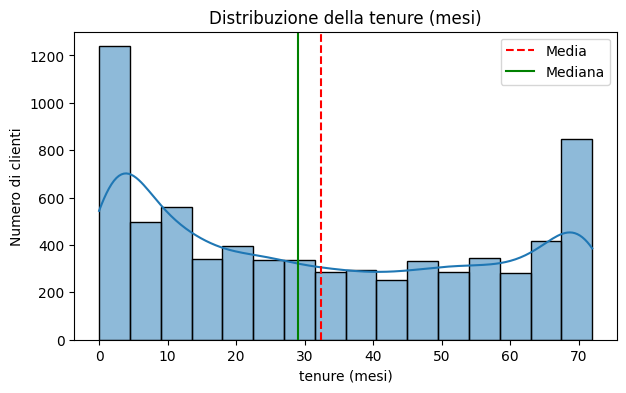

In [46]:
# Visualizziamo graficamente la distribuzione della variabile 'tenure'

plt.figure(figsize=(7, 4))
sns.histplot(df["tenure"], kde=True)
plt.axvline(df["tenure"].mean(),   color="red",   linestyle="--", label="Media")
plt.axvline(df["tenure"].median(), color="green", linestyle="-",  label="Mediana")
plt.title("Distribuzione della tenure (mesi)")
plt.xlabel("tenure (mesi)")
plt.ylabel("Numero di clienti")
plt.legend()
plt.show()

L'istogramma rivela una **distribuzione bimodale**: una forte concentrazione di clienti molto recenti (tenure vicina a 0) e una seconda concentrazione di clienti di lunga data (vicini ai 72 mesi), con la zona centrale meno popolata. Media e mediana cadono proprio in quest'area intermedia, segnalando la presenza di **due gruppi distinti**: nuovi clienti e clienti storici.

## D5: Come si distribuiscono le variabili di spesa MonthlyCharges (canone mensile) e TotalCharges (spesa cumulata)?

In [47]:
# Misure di centralità (media e mediana), deviazione standard e range dei valori della variabile 'Monthly Charges'
media_monthly_charges = df["MonthlyCharges"].mean()
mediana_monthly_charges = df["MonthlyCharges"].median()
deviazione_standard_monthly_charges = df["MonthlyCharges"].std()
min_monthly_charges = df["MonthlyCharges"].min()
max_monthly_charges = df["MonthlyCharges"].max()

# La variabile 'Total Charges' viene letta da pandas come testo e non come numero a causa degli 11 valori vuoti bisogna quindi prima convertirla.

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# errors=coerce dice "se trovi un valore che non riesci a convertire (lo spazio vuoto), non bloccarti: trasformalo in NaN"
# Adesso possiamo procedere con i calcoli di media, mediana, deviazione standard e range dei valori
media_total_charges = df["TotalCharges"].mean()
mediana_total_charges = df["TotalCharges"].median()
deviazione_standard_total_charges = df["TotalCharges"].std()
min_total_charges = df["TotalCharges"].min()
max_total_charges = df["TotalCharges"].max()

print(f"MonthlyCharges: media = {media_monthly_charges:.2f}, mediana = {mediana_monthly_charges:.2f}, std = {deviazione_standard_monthly_charges:.2f}, min = {min_monthly_charges:.2f}, max = {max_monthly_charges:.2f}")
print(f"TotalCharges: media = {media_total_charges:.2f}, mediana = {mediana_total_charges:.2f}, std = {deviazione_standard_total_charges:.2f}, min = {min_total_charges:.2f}, max = {max_total_charges:.2f}")



MonthlyCharges: media = 64.76, mediana = 70.35, std = 30.09, min = 18.25, max = 118.75
TotalCharges: media = 2283.30, mediana = 1397.47, std = 2266.77, min = 18.80, max = 8684.80


Per `MonthlyCharges` la media è **64,8** e la mediana **70,4**: la media leggermente inferiore alla mediana suggerisce una possibile asimmetria. I valori si distribuiscono tra **18,3** e **118,8**, con deviazione standard di **30,1**.

Per `TotalCharges` lo scarto è molto più ampio (media **2.283,3** contro mediana **1.397,5**): la media nettamente superiore alla mediana indica che pochi clienti con spesa cumulata elevata alzano il valore medio. Lo confermano l'intervallo molto esteso (da **18,8** a **8.684,8**) e una deviazione standard di **2.266,8**, quasi pari alla media stessa, segnale di una variabilità molto marcata. Questa è un'ipotesi sulla forma delle distribuzioni che verificheremo nella fase di analisi esplorativa.

###Distribuzione di MonthlyCharges

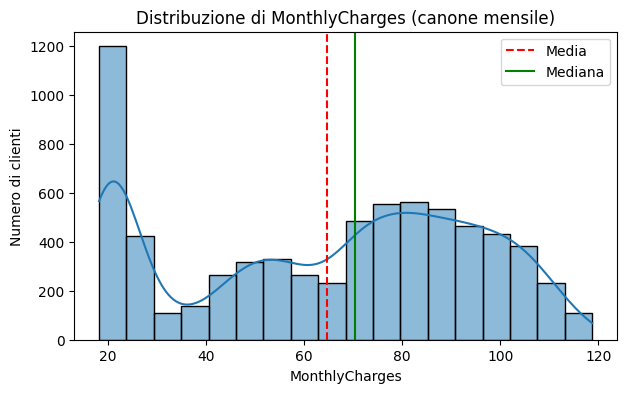

In [48]:
# Visualizziamo graficamente la distribuzione della variabile 'Monthly Charges'

plt.figure(figsize=(7, 4))
sns.histplot(df["MonthlyCharges"], kde=True)
plt.axvline(df["MonthlyCharges"].mean(),   color="red",   linestyle="--", label="Media")
plt.axvline(df["MonthlyCharges"].median(), color="green", linestyle="-",  label="Mediana")
plt.title("Distribuzione di MonthlyCharges (canone mensile)")
plt.xlabel("MonthlyCharges")
plt.ylabel("Numero di clienti")
plt.legend()
plt.show()

Anche in questo caso la distribuzione è **bimodale**: un picco marcato sui valori più bassi (intorno ai 20€) e un'ampia concentrazione sui valori medio-alti (tra 70 e 110€ circa), separati da una fascia intermedia meno densa. Questo suggerisce **due profili di clientela con livelli di servizio differenti**, una struttura che la sola vicinanza tra media e mediana non lasciava prevedere.

###Distribuzione di TotalCharges

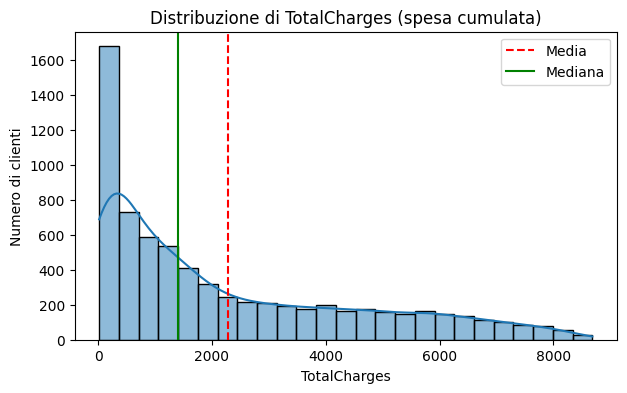

In [49]:
# Visualizziamo graficamente la distribuzione della variabile 'Total Charges'

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
plt.figure(figsize=(7, 4))
sns.histplot(df["TotalCharges"], kde=True)
plt.axvline(df["TotalCharges"].mean(),   color="red",   linestyle="--", label="Media")
plt.axvline(df["TotalCharges"].median(), color="green", linestyle="-",  label="Mediana")
plt.title("Distribuzione di TotalCharges (spesa cumulata)")
plt.xlabel("TotalCharges")
plt.ylabel("Numero di clienti")
plt.legend()
plt.show()

L'istogramma mostra una marcata **asimmetria**: i clienti si concentrano sui valori bassi di spesa cumulata, con una lunga coda verso destra. La linea della media cade visibilmente a destra della mediana: è la rappresentazione grafica dello scarto tra i due valori osservato in precedenza, dovuto ai pochi clienti con spesa molto elevata.

 ## D6: Analizziamo la composizione demografica del campione (variabili genere, SeniorCitizen, partner, dependents)

### Genere

In [50]:
# Conteggio
conteggi_gen = df["gender"].value_counts()
print(conteggi_gen)

# Percentualizzo
totale_clienti = len(df)
percentuale_m = ((conteggi_gen["Male"] / totale_clienti) * 100).round(2)
percentuale_f = ((conteggi_gen["Female"] / totale_clienti) * 100).round(2)

print("La percentuale di maschi è:", percentuale_m,"%")
print("La percentuale di femmine è:", percentuale_f,"%")

gender
Male      3555
Female    3488
Name: count, dtype: int64
La percentuale di maschi è: 50.48 %
La percentuale di femmine è: 49.52 %


Il genere è perfettamente bilanciato: i clienti di sesso maschile sono il 50.48% e quelli di sesso femminile il 49.52%.

### SeniorCitizen (essere cittadino senior o no)

In [51]:
# Conteggio
conteggi_SenCit = df["SeniorCitizen"].value_counts()
print(conteggi_SenCit)

# Percentualizzo
totale_clienti = len(df)
percentuale_sen = ((conteggi_SenCit[1] / totale_clienti) * 100).round(2)
percentuale_NoSen = ((conteggi_SenCit[0] / totale_clienti) * 100).round(2)

print("La percentuale di cittadini senior è:", percentuale_sen, "%")
print("La percentuale di cittadini non senior è:", percentuale_NoSen ,"%")

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
La percentuale di cittadini senior è: 16.21 %
La percentuale di cittadini non senior è: 83.79 %


Circa l'84% dei clienti è giovane, contro un 16% di clienti senior: la variabile è quindi fortemente sbilanciata.

### Partner

In [52]:
# Conteggio
conteggi_part = df["Partner"].value_counts()
print(conteggi_part)

# Percentualizzo
totale_clienti = len(df)
percentuale_PYes = ((conteggi_part["Yes"] / totale_clienti) * 100).round(2)
percentuale_PNo = ((conteggi_part["No"] / totale_clienti) * 100).round(2)

print("La percentuale di clienti con partner è:", percentuale_PYes, "%")
print("La percentuale di clienti senza partner è:", percentuale_PNo, "%")

Partner
No     3641
Yes    3402
Name: count, dtype: int64
La percentuale di clienti con partner è: 48.3 %
La percentuale di clienti senza partner è: 51.7 %


Questa variabile è bilanciata, possiamo notare che le due categorie differiscono di pochi punti percentuali, circa metà dei clienti ha un partner e l'altra metà non ce l'ha.

###Dependents (avere una persona a carico o no)

In [53]:
# Conteggio
conteggi_dep = df["Dependents"].value_counts()
print(conteggi_dep)

# Percentualizzo
totale_clienti = len(df)
percentuale_DYes = ((conteggi_dep["Yes"] / totale_clienti) * 100).round(2)
percentuale_DNo = ((conteggi_dep["No"] / totale_clienti) * 100).round(2)

print("La percentuale di clienti con persone a carico è:", percentuale_DYes, "%")
print("La percentuale di clienti senza persone a carico è:", percentuale_DNo, "%")

Dependents
No     4933
Yes    2110
Name: count, dtype: int64
La percentuale di clienti con persone a carico è: 29.96 %
La percentuale di clienti senza persone a carico è: 70.04 %


Notiamo che il 70% dei clienti non hanno persone a carico, a fronte di un 30% di clienti che le ha.

## D7: Come sono distribuiti i servizi di rete? (PhoneService, MultipleLines e InternetService)

Queste variabili sono
candidati naturali a predire il churn (si protrebbe ipotizzare che un cliente più "agganciato" all'ecosistema di servizi
potrebbe essere più fedele).

### Phone Service

In [54]:
# Conteggio
conteggi_phone = df["PhoneService"].value_counts()
print(conteggi_phone)

# Percentualizzo
totale_clienti = len(df)
percentuale_PhYes = ((conteggi_phone["Yes"] / totale_clienti) * 100).round(2)
percentuale_PhNo = ((conteggi_phone["No"] / totale_clienti) * 100).round(2)

print("La percentuale di clienti hanno un Phone Service è:", percentuale_PhYes, "%")
print("La percentuale di clienti senza un Phone Service è:", percentuale_PhNo, "%")

PhoneService
Yes    6361
No      682
Name: count, dtype: int64
La percentuale di clienti hanno un Phone Service è: 90.32 %
La percentuale di clienti senza un Phone Service è: 9.68 %


Il 90% dei clienti ha un servizio telefonico: variabile molto sbilanciata e quindi poco
informativa da sola.

### Multiple Lines

In [55]:
# Conteggio
conteggi_lines = df["MultipleLines"].value_counts()
print(conteggi_lines)

# Percentualizzo
totale_clienti = len(df)
percentuale_no_lines = ((conteggi_lines["No"] / totale_clienti) * 100).round(2)
percentuale_si_lines = ((conteggi_lines["Yes"] / totale_clienti) * 100).round(2)
# La percentuale dei clienti senza un phone service l'abbiamo già calcolata prima
percentuale_PhNo = ((conteggi_phone["No"] / totale_clienti) * 100).round(2)

print("La percentuale di clienti che non ha linee multiple è:", percentuale_no_lines)
print("La percentuale di clienti che ha linee multiple è:", percentuale_si_lines)
print("La percentuale di No phone service è:", percentuale_PhNo)

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
La percentuale di clienti che non ha linee multiple è: 48.13
La percentuale di clienti che ha linee multiple è: 42.18
La percentuale di No phone service è: 9.68


Tra i clienti che possiedono una linea telefonica, circa il 42% ha attivato l'opzione delle linee multiple, mentre il 48% mantiene una linea singola. Come abbiamo evidenziato nell'analisi precedente, una piccola fetta di clienti (circa il 10%) non ha un servizio telefonico.

### Internet Service

In [56]:
# Conteggio
conteggi_IntSer = df["InternetService"].value_counts()
print(conteggi_IntSer)

# Percentualizzo
totale_clienti = len(df)
percentuale_DSL = ((conteggi_IntSer["DSL"] / totale_clienti) * 100).round(2)
percentuale_Fiber = ((conteggi_IntSer["Fiber optic"] / totale_clienti) * 100).round(2)
percentuale_NoIntSer = ((conteggi_IntSer["No"] / totale_clienti) * 100).round(2)

print("La percentuale di clienti che hanno un servizio internet DSL è:", percentuale_DSL)
print("La percentuale di clienti che hanno un servizio internet Fiber optic è:", percentuale_Fiber)
print("La percentuale di clienti senza un servizio internet è:", percentuale_NoIntSer)

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
La percentuale di clienti che hanno un servizio internet DSL è: 34.37
La percentuale di clienti che hanno un servizio internet Fiber optic è: 43.96
La percentuale di clienti senza un servizio internet è: 21.67


Circa il 34% dei clienti ha un servizio internet DSL, il 44% un servizio di fibra ottica e il 22% non ha un servizio internet.

Per visualizzare meglio la distribuzione della tipologia di Internet Service possiamo fare un grafico a barre:

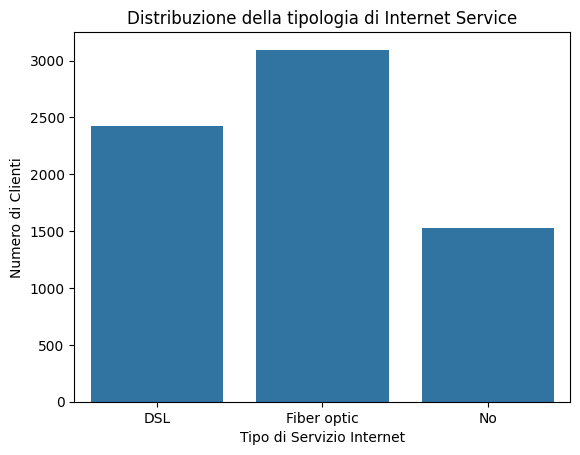

In [57]:
# Grafico per la distribuzione del servizio Internet
sns.countplot(data=df, x="InternetService")
plt.title("Distribuzione della tipologia di Internet Service")
plt.xlabel("Tipo di Servizio Internet")
plt.ylabel("Numero di Clienti")
plt.show()

Qui risulta ancora più evidente che la maggior parte dei clienti hanno un servizio di fiber optic (fibra ottica).

## D8: Come si distribuiscono le variabili dei servizi di supporto e intrattenimento?

### Online Security, Online Backup, Device Protection, Tech Support, StreamingTV, Streaming Movies

Questi sei servizi condividono la stessa struttura a tre categorie (Yes / No / No internet
service) ed esistono solo per i clienti che hanno un servizio internet. Li analizziamo
insieme con un ciclo.

In [58]:
# 1. Creiamo una lista con tutti i servizi aggiuntivi che vogliamo analizzare
servizi_aggiuntivi = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

# totale clienti
totale_clienti = len(df)

# 2. Facciamo partire il ciclo che esamina un servizio alla volta
for servizio in servizi_aggiuntivi:

    print(f"\n ANALISI SERVIZIO: {servizio} ")

    # Conteggio per il servizio corrente
    conteggi = df[servizio].value_counts()
    print(conteggi)

    # Calcolo delle percentuali
    percentuale_no = ((conteggi["No"] / totale_clienti) * 100).round(2)
    percentuale_si = ((conteggi["Yes"] / totale_clienti) * 100).round(2)
    percentuale_no_internet = ((conteggi["No internet service"] / totale_clienti) * 100).round(2)

    # Stampiamo i risultati
    print(f"La percentuale di No è: {percentuale_no}%")
    print(f"La percentuale di Yes è: {percentuale_si}%")
    print(f"La percentuale di No internet service è: {percentuale_no_internet}%")


 ANALISI SERVIZIO: OnlineSecurity 
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
La percentuale di No è: 49.67%
La percentuale di Yes è: 28.67%
La percentuale di No internet service è: 21.67%

 ANALISI SERVIZIO: OnlineBackup 
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
La percentuale di No è: 43.84%
La percentuale di Yes è: 34.49%
La percentuale di No internet service è: 21.67%

 ANALISI SERVIZIO: DeviceProtection 
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64
La percentuale di No è: 43.94%
La percentuale di Yes è: 34.39%
La percentuale di No internet service è: 21.67%

 ANALISI SERVIZIO: TechSupport 
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64
La percentuale di No è: 49.31

Premessa comune: in tutti e sei i servizi la categoria "No internet service" vale circa il
21.67%, esattamente la quota di clienti senza internet già vista in D7.

**Servizi di protezione/supporto — la maggioranza dei clienti non li ha:**
- OnlineSecurity: 50% No contro 29% Yes
- OnlineBackup: 44% No contro 34% Yes
- DeviceProtection: 44% No contro 34% Yes
- TechSupport: 50% No contro 29% Yes

**Servizi di intrattenimento — sostanzialmente in equilibrio:**
- StreamingTV: 40% Yes / 40% No
- StreamingMovies: 40% Yes / 40% No

I due servizi di streaming hanno distribuzioni quasi identiche

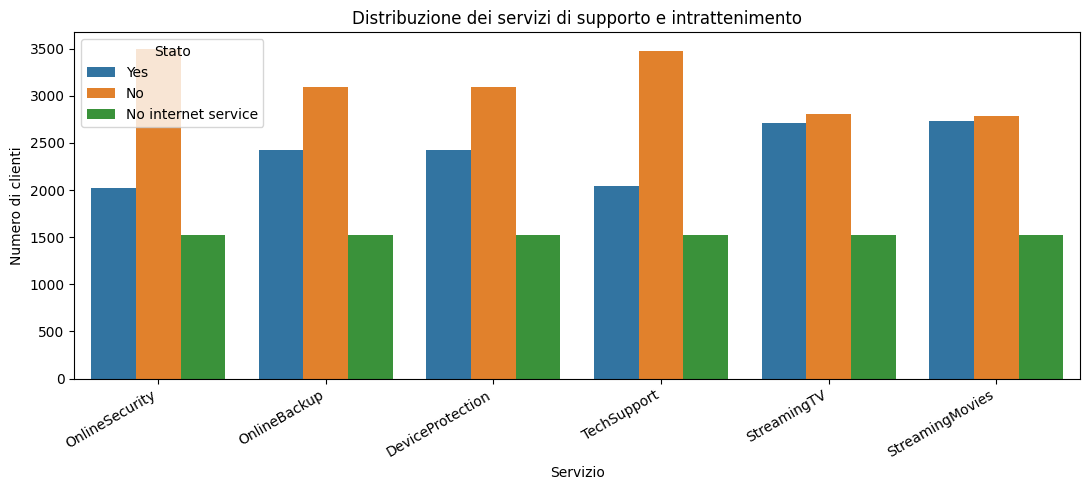

In [59]:
# Grafico comparativo dei sei servizi aggiuntivi
servizi_aggiuntivi = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

# Trasformiamo il dataframe in formato "lungo": una riga per ogni coppia (servizio, valore)
# così seaborn può disegnare tutti i servizi affiancati in un unico countplot
df_servizi = df[servizi_aggiuntivi].melt(var_name="Servizio", value_name="Stato")

plt.figure(figsize=(11, 5))
sns.countplot(
    data=df_servizi,
    x="Servizio",
    hue="Stato",
    hue_order=["Yes", "No", "No internet service"]
)
plt.title("Distribuzione dei servizi di supporto e intrattenimento")
plt.xlabel("Servizio")
plt.ylabel("Numero di clienti")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Stato")
plt.tight_layout()
plt.show()

Si vede a colpo d'occhio che nei servizi di protezione (OnlineSecurity, TechSupport)
la barra "No" domina, mentre nei due servizi di streaming le barre "Yes" e "No" sono quasi
pari — coerente con quanto osservato sopra.

## D9: Distribuzione delle modalità di fatturazione e dei vincoli contrattuali

### Metodo di pagamento

In [60]:
# Conteggio
conteggi_pagamento = df["PaymentMethod"].value_counts()
print(conteggi_pagamento)

# Percentualizzo
percentuale_electronic = ((conteggi_pagamento["Electronic check"] / totale_clienti) * 100).round(2)
percentuale_mailed = ((conteggi_pagamento["Mailed check"] / totale_clienti) * 100).round(2)
percentuale_bank = ((conteggi_pagamento["Bank transfer (automatic)"] / totale_clienti) * 100).round(2)
percentuale_credit = ((conteggi_pagamento["Credit card (automatic)"] / totale_clienti) * 100).round(2)

# Risultati
print("La percentuale di clienti che utilizza l'Electronic check è:", percentuale_electronic)
print("La percentuale di clienti che utilizza il Mailed check è:", percentuale_mailed)
print("La percentuale di clienti che utilizza il Bank transfer (automatic) è:", percentuale_bank)
print("La percentuale di clienti che utilizza la Credit card (automatic) è:", percentuale_credit)

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64
La percentuale di clienti che utilizza l'Electronic check è: 33.58
La percentuale di clienti che utilizza il Mailed check è: 22.89
La percentuale di clienti che utilizza il Bank transfer (automatic) è: 21.92
La percentuale di clienti che utilizza la Credit card (automatic) è: 21.61


- L'electronick check è il metodo di pagamento più utilizzato, scelto da oltre un terzo dei clienti (33.58%)

- I metodi di pagamento automatici (Back transfer e la Credit Card) sono utilizzati da due fette di clienti, ciascuna delle quali rappresenta circa il 22% dei clienti.

- Il metodo di pagamento più tradizionale, ovvero il mailed check, è utilizzato dal 23% dei clienti.

### Tipo di contratto

In [61]:
# Conteggio
conteggi_contratto = df["Contract"].value_counts()
print(conteggi_contratto)

# Percentualizzo
percentuale_mese = ((conteggi_contratto["Month-to-month"] / totale_clienti) * 100).round(2)
percentuale_anno = ((conteggi_contratto["One year"] / totale_clienti) * 100).round(2)
percentuale_biennio = ((conteggi_contratto["Two year"] / totale_clienti) * 100).round(2)

# Risultati
print("La percentuale di clienti che scelgono un contratto Mese per Mese è:", percentuale_mese)
print("La percentuale di clienti che scelgono un contratto Annuale è:", percentuale_anno)
print("La percentuale di clienti che scelgono un contratto Biennale è:", percentuale_biennio)

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64
La percentuale di clienti che scelgono un contratto Mese per Mese è: 55.02
La percentuale di clienti che scelgono un contratto Annuale è: 20.91
La percentuale di clienti che scelgono un contratto Biennale è: 24.07


- La metà dei clienti (55%) scelgono un contratto che si rinnova mese per mese

- Il 21% dei clienti ha scelto un contratto Annuale e il 24% dei clienti ha scelto un contratto Biennale

Nel seguende grafico possiamo mostrare la grande sproporzione tra chi sceglie un contratto mese per mese e chi sceglie un contratto di uno o due anni:

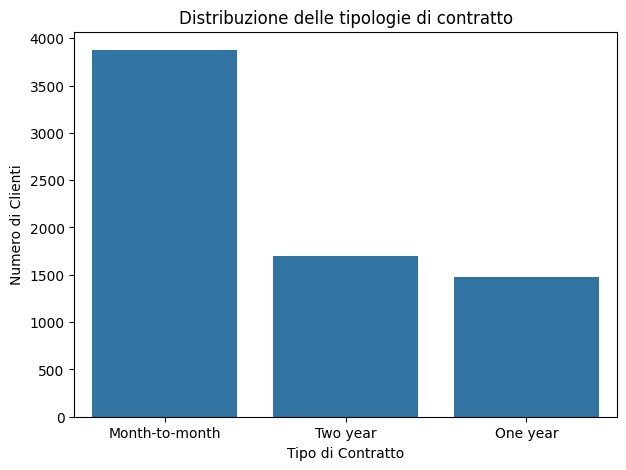

In [62]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Contract", order=df["Contract"].value_counts().index)

plt.title("Distribuzione delle tipologie di contratto")
plt.xlabel("Tipo di Contratto")
plt.ylabel("Numero di Clienti")

plt.show()

#Fase 2:  Analisi esplorativa e visualizzazione

## D1: I clienti con contratto mensile abbandonano maggiormente?

**Ipotesi**: i contratti Month-to-month presentano un tasso di churn nettamente superiore rispetto ai contratti annuali e biennali.

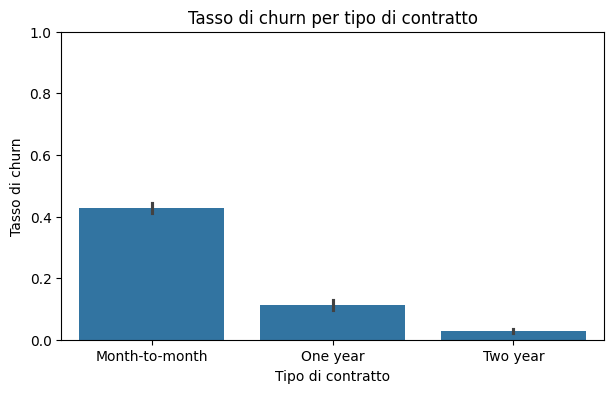

In [63]:
# Convertiamo Churn (testo "Yes"/"No") in numerico (1/0) usando .map

plt.figure(figsize=(7, 4))
sns.barplot(data=df, x="Contract", y=df["Churn"].map({"No": 0, "Yes": 1}))
plt.title("Tasso di churn per tipo di contratto")
plt.xlabel("Tipo di contratto")
plt.ylabel("Tasso di churn")
plt.ylim(0, 1)
plt.show()

Il barplot conferma l'ipotesi: il tasso di churn dei contratti *Month-to-month* è nettamente più alto, attorno al **40%**, mentre scende a circa il **10%** per i *contratti annuali* e a **pochi punti percentuali** per i *biennali*.
La durata del contratto risulta quindi fortemente associata all'abbandono: i clienti senza vincolo temporale abbandonano molto più spesso.

## D2:  Come si distribuisce la variabile `tenure` tra chi abbandona e chi resta?

**Ipotesi**: i clienti che abbandonano hanno un'anzianità inferiore, ovvero tendono a lasciare il servizio nei primi mesi.

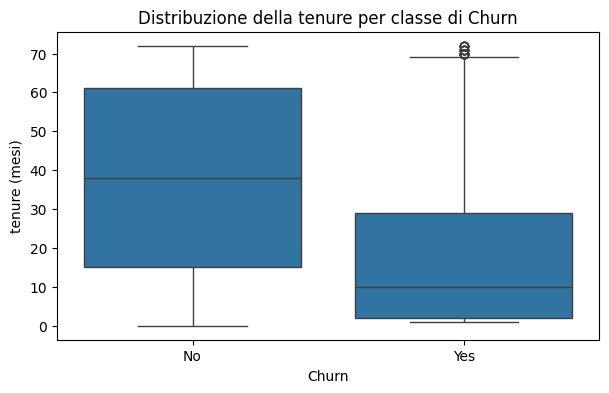

In [64]:
# Boxplot della tenure separata per classe di Churn
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Distribuzione della tenure per classe di Churn")
plt.xlabel("Churn")
plt.ylabel("tenure (mesi)")
plt.show()

Il boxplot conferma con chiarezza l'ipotesi: la distribuzione della tenure di chi abbandona è interamente spostata verso il basso rispetto a chi resta. I clienti che fanno churn hanno una tenure mediana di circa **10 mesi**, contro i circa **38 mesi** di chi rimane, e anche la loro metà centrale si concentra nei primi mesi di rapporto. L'abbandono si verifica quindi soprattutto all'inizio della relazione con l'azienda. Si nota inoltre un piccolo gruppo di clienti con tenure elevata che abbandonano comunque (valori anomali nel gruppo "Yes"): un'eccezione che potrebbe meritare un approfondimento. Il risultato conferma quanto emerso nella fase descrittiva: gran parte dei clienti che abbandonano si trova tra quelli con pochi mesi di anzianità.

## D3: Le variabili di spesa sono correlate tra loro e con `tenure`?

**Ipotesi**: `TotalCharges` è fortemente correlata sia con `tenure` sia con `MonthlyCharges`, confermando la ridondanza individuata nella fase di comprensione del dataset.

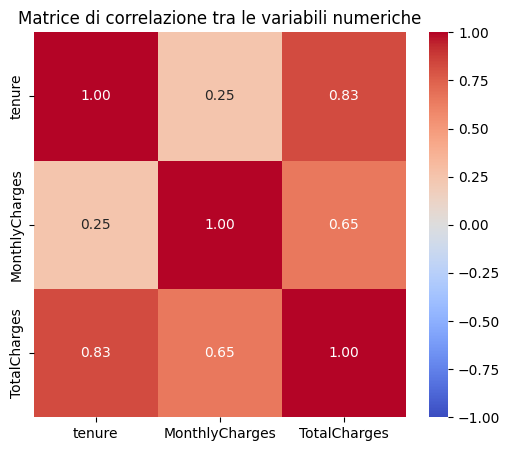

In [65]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Selezioniamo solo le variabili numeriche di interesse
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
corr = df[num_cols].corr()   # calcola la matrice di correlazione

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matrice di correlazione tra le variabili numeriche")
plt.show()

La heatmap conferma l'ipotesi e mostra la ridondanza già notata nella fase di descrizione del dataset. `TotalCharges` è molto legata a `tenure` (**0,83**) e abbastanza a` MonthlyCharges `(**0,65**), mentre `tenure` e `MonthlyCharges` hanno poco a che fare l'una con l'altra (**0,25**). Il motivo è intuitivo: la spesa totale dipende da quanti mesi il cliente è rimasto e da quanto paga ogni mese, quindi racchiude in sé l'informazione delle altre due variabili. In fase di modellazione sarà bene tenerne conto, valutando se usare tutte e tre le variabili o eliminarne una per evitare di ripetere la stessa informazione.

##D4: I clienti senior fanno più `churn`?

**Ipotesi**: I clienti `SeniorCitizen` (=1) sono più propensi ad abbandonare il servizio, in quanto potenzialmente meno fidelizzati o più sensibili al prezzo rispetto ai clienti più giovani.

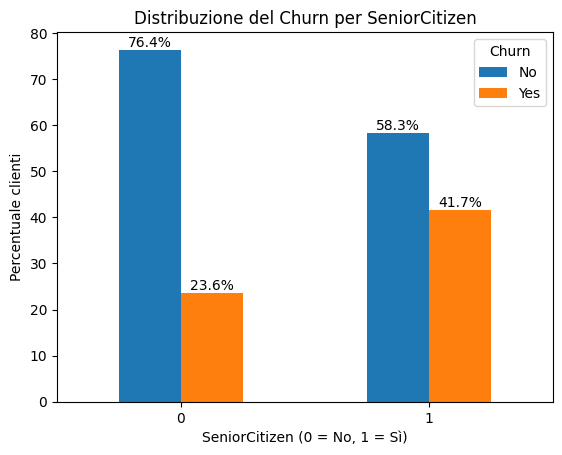

In [66]:
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100
ax = ct.plot(kind='bar')
plt.title('Distribuzione del Churn per SeniorCitizen')
plt.xlabel('SeniorCitizen (0 = No, 1 = Sì)')
plt.ylabel('Percentuale clienti')
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.show()

I dati confermano l'ipotesi iniziale: il tasso di `churn` tra i clienti senior è del **41,7%**, contro il **23,6%** registrato tra i non senior — quasi il doppio. Questo significa che, a parità di altre condizioni, un cliente senior ha una probabilità molto più alta di abbandonare il servizio rispetto a un cliente non senior. Va comunque considerato che i clienti senior rappresentano solo il 16% circa del dataset (1.142 su 7.043), quindi pur essendo un segmento minoritario, è quello a maggior rischio di abbandono e potrebbe meritare interventi di retention dedicati.

Il dataset però non contiene informazioni su reddito o utilizzo dei servizi che permettano di verificare la causa specifica di questa differenza. Resta quindi confermata la correlazione, non la spiegazione causale ipotizzata.



## D5: Esiste una relazione tra `MonthlyCharges`, `tenure` e il `churn`?

**Ipotesi**: I clienti che abbandonano tendano ad avere una spesa mensile alta e una tenure bassa, ovvero che paghino molto pur essendo clienti relativamente recenti.

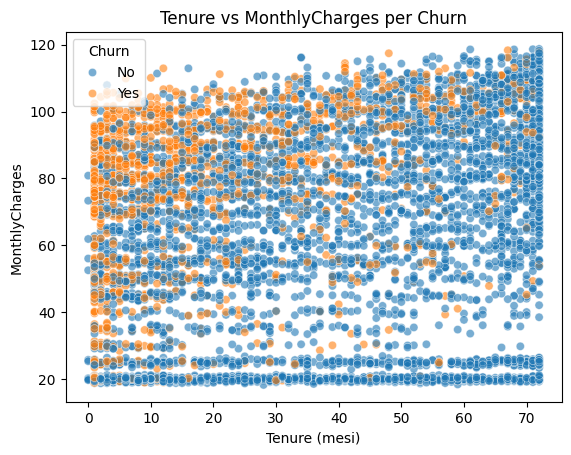

,tenure,MonthlyCharges
Churn,,
No,37.6,61.3
Yes,18.0,74.4


In [67]:
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', alpha=0.6)
plt.title('Tenure vs MonthlyCharges per Churn')
plt.xlabel('Tenure (mesi)')
plt.ylabel('MonthlyCharges')
plt.show()

# Statistiche tenure e MonthlyCharges per gruppo Churn
df.groupby('Churn')[['tenure', 'MonthlyCharges']].mean().round(1)

I dati la confermano l'ipotesi iniziale: chi fa `churn` ha una `tenure` media di circa **18 mesi**, contro **37,6 mesi** per chi resta, e una spesa mensile media più alta (**74,4€** contro **61,3€**). Lo scatterplot mostra infatti i punti del `Churn` concentrati nella zona a bassa `tenure` e alta spesa, suggerendo che il rischio di abbandono è massimo nei primi mesi del rapporto contrattuale, specialmente per i piani più costosi.

**Ipotesi Domande 6 - 8**
---
Prima di entrare nel dettaglio dell'analisi, ipotizziamo che esista una forte
interconnessione tra i costi, i servizi attivi e la stabilità del cliente. Nello specifico, ipotizziamo che l'assenza di familiari a carico (Dependents = No) lasci il cliente più libero di valutare alternative di mercato, e che la combinazione tra abbonamenti costosi (MonthlyCharges elevati) e l'uso della fibra ottica (InternetService) costituisca un elemento di forte sensibilità al prezzo, rendendo questi utenti più propensi ad abbandonare la compagnia (Churn = Yes) davanti a offerte concorrenti.

## D6: Esiste una relazione tra `Dependents` e la `MonthlyCharges`?

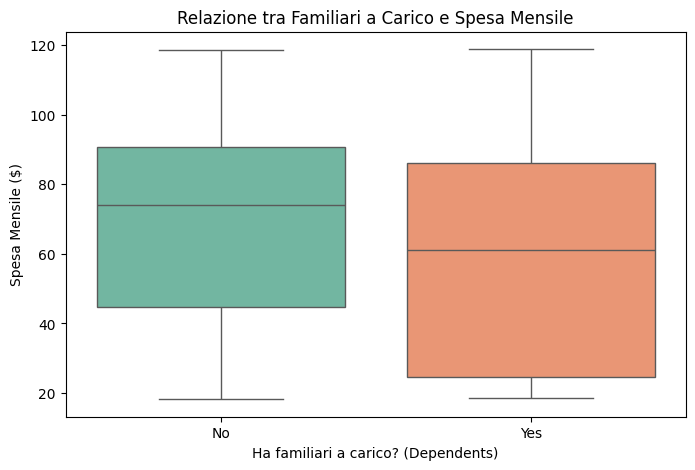

In [68]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Dependents", y="MonthlyCharges", palette="Set2", hue="Dependents")

plt.title("Relazione tra Familiari a Carico e Spesa Mensile")
plt.xlabel("Ha familiari a carico? (Dependents)")
plt.ylabel("Spesa Mensile ($)")

plt.show()

- **Spesa mediana:** : I clienti *senza familiari a carico* hanno una spesa mensile mediana più alta dei clienti che hanno familiari a carico.

- **Distribuzione**: Il box del gruppo dei clenti *con familiari a carico* si estende molto verso il basso. Questo vuol dire che i loro contratti sono tendenzialmente economici.

Sembra che i clienti *con familiari a carico* tendano a "ottimizzare i costi" e scegliere abbonamenti più economici.

## D7: Esiste una relazione tra `PaymenthMethod` e `MonthlyCharges`?

/tmp/ipykernel_6068/2544209649.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="PaymentMethod", y="MonthlyCharges", palette="Set3")


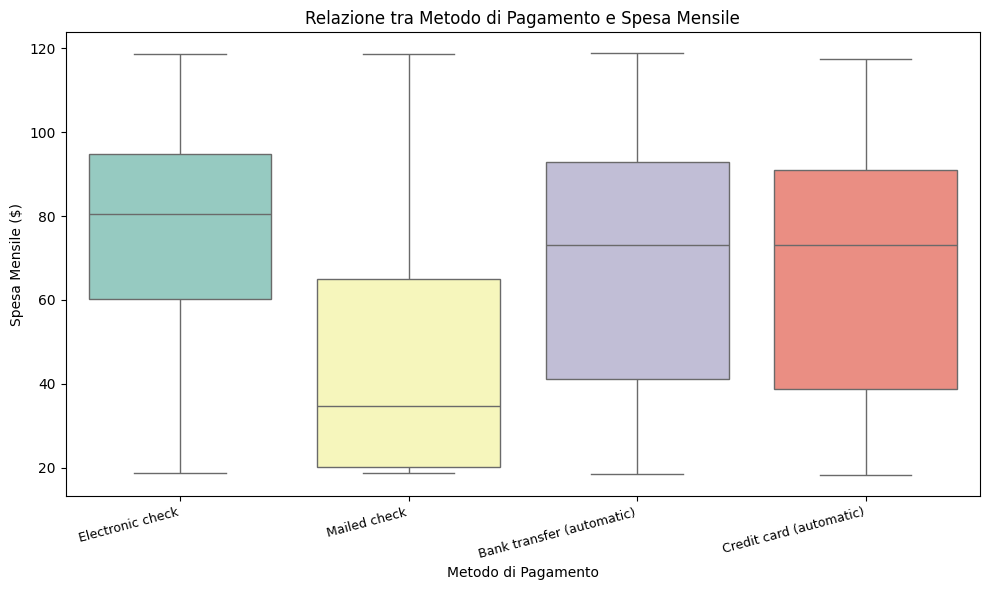

In [69]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x="PaymentMethod", y="MonthlyCharges", palette="Set3")

plt.title("Relazione tra Metodo di Pagamento e Spesa Mensile")
plt.xlabel("Metodo di Pagamento")
plt.ylabel("Spesa Mensile ($)")

# Ruotiamo i testi per non farli sovrapporre
plt.xticks(rotation=15, ha="right", fontsize= 9)

plt.tight_layout()
plt.show()

- **Mailed check (Assegno cartaceo)**: Presenta la spesa mediana più bassa in assoluto (circa 35 euro). La scatola è fortemente schiacciata verso il basso, segno che questo metodo è utilizzato prevalentemente da utenti con piani tariffari base.

- **Electronic check (Assegno elettronico)**: Registra la spesa mediana più alta (circa 80 euro). Oltre il 50% di questi clienti spende tra i 60 euro e i 95 euro al mese, indicando una forte adozione di pacchetti più costosi.

- **Metodi Automatici (Bank transfer / Credit card)**: Hanno un comportamento simile tra loro, con una spesa mediana identica di circa 73 euro.

## D8: Esiste una relazione tra `InternetService` e `Churn` ?

/tmp/ipykernel_6068/879980046.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


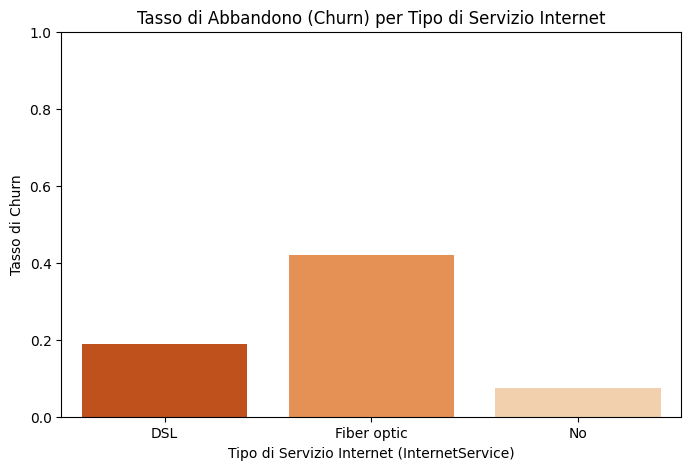

In [70]:
plt.figure(figsize=(8, 5))

# Creiamo il barplot: mappiamo Churn (Yes/No) in (1/0) per calcolare la percentuale media
# Abbiamo deciso di mappare per creare il "tasso di churn":
# ogni volta che c'è "Yes" lo trasforma in 1 e quando c'è "No" in 0.
# in questo modo possiamo calcolare la percentuale di churn

sns.barplot(
    data=df,
    x="InternetService",
    y=df["Churn"].map({"Yes": 1, "No": 0}),
    palette="Oranges_r",
    errorbar=None
)

# facciamo in modo che l'asse y vari da 0% a 100%

plt.ylim(0, 1)

# Dettagli per la leggibilità
plt.title("Tasso di Abbandono (Churn) per Tipo di Servizio Internet")
plt.xlabel("Tipo di Servizio Internet (InternetService)")
plt.ylabel("Tasso di Churn")

plt.show()

- **Fiber optic (Fibra ottica)**: Registra il tasso di abbandono più critico, sfiorando il **42%.** Quasi un cliente su due tra chi sceglie la fibra decide di chiudere il contratto telefonico.

- **DSL**: Mostra una stabilità decisamente maggiore, con un tasso di Churn che si ferma intorno al 19%.

- **Nessun servizio internet**: I clienti che non hanno un abbonamento internet (probabilmente utenti che hanno attivo solo il servizio di telefonia) sono i più fedeli, con un tasso di abbandono minimo, inferiore al 10%.

In conclusione, riprendendo l'ipotesi iniziale, i dati smentiscono l'idea che i clienti con abbonamenti più costosi o tecnologicamente avanzati siano i più fedeli. Al contrario, **il profilo più propenso all'abbandono** è caratterizzato da chi ha:
- connessione in Fiber Optic (Fibra Ottica)
- Spesa mensile elevata
- Pagamento con Electronick Check

Mentre i profili più fedeli sono:
- Chi non ha nessun servizio internet (solo servizio telefonico)
- Chi ha familiari a carico, i quali mostrano una spesa mediana più bassa (circa 61 euro) e una maggiore stabilità.

#Fase 3: Modellazione

I modelli predittivi (Logistic Regression, Decision Tree, Random Forest) richiedono input esclusivamente numerici, quindi è necessario trasformare tutte le variabili categoriche e gestire i valori mancanti prima del train/test split.

In particolare:
* `TotalCharges` viene convertita da stringa a float (le 11 righe vuote vengono rimosse)
* `customerID` viene eliminato perché è un identificativo univoco senza valore predittivo
* `Churn` (target) viene mappata manualmente in 0/1 per avere un controllo esplicito sulla codifica
* tutte le altre variabili categoriche vengono trasformate in variabili dummy (one-hot encoding)

In [71]:
# Conversione TotalCharges da stringa a float (rimandata dalla Fase 2/3)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df_modificato = df.dropna(subset=['TotalCharges'])  # 11 righe con valore vuoto, trascurabili

In [72]:
# Rimozione customerID (non predittivo)
df_modificato = df_modificato.drop(columns=['customerID'])

In [73]:
# Convertiamo manualemnte Churn (variabile target)
df_modificato['Churn'] = df_modificato['Churn'].map({'No': 0, 'Yes': 1})

In [74]:
# Convertiamo tutte le altre variabili in dummies
df_modificato = pd.get_dummies(df_modificato, drop_first=True, dtype=int)

In [75]:
df_modificato.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   Churn                                  7032 non-null   int64  
 5   gender_Male                            7032 non-null   int64  
 6   Partner_Yes                            7032 non-null   int64  
 7   Dependents_Yes                         7032 non-null   int64  
 8   PhoneService_Yes                       7032 non-null   int64  
 9   MultipleLines_No phone service         7032 non-null   int64  
 10  MultipleLines_Yes                      7032 non-null   int64  
 11  InternetS

In [76]:
df_modificato.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


Salvataggio del dataset pre-elaborato (numerico, pronto per
il train/test split e l'addestramento dei modelli), così da poterlo riutilizzare senza dover
rieseguire ogni volta tutto il preprocessing.


In [77]:
# Scarico il dataframe convertito
from google.colab import files

df_modificato.to_csv('Customer_Churn_convertito.csv', index=False)
files.download('Customer_Churn_convertito.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Divisione del dataset in train e test: necessaria per addestrare i modelli su una parte dei dati (train) e valutarne le prestazioni su dati non visti (test).

In [78]:
from sklearn.model_selection import train_test_split

In [79]:
X = df_modificato.drop(columns=['Churn'])
Y = df_modificato['Churn']

# Stratify per mantenere la stessa proporzione di classi (class imbalance vista in Fase 2)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.30, random_state=42, stratify=Y
)

Il dataset è stato diviso in 70% train e 30% test (come indicato dal docente), usando stratify=y per mantenere lo stesso rapporto tra clienti che abbandonano e clienti che restano in entrambi i set — fondamentale dato lo squilibrio di classe (~73,5% No / ~26,5% Yes) osservato in Fase 2.

In [80]:
print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Proporzione Churn train:', Y_train.mean().round(3))
print('Proporzione Churn test:', Y_test.mean().round(3))

Train shape: (4922, 30)
Test shape: (2110, 30)
Proporzione Churn train: 0.266
Proporzione Churn test: 0.266


In [81]:
X_train.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
4499,0,12,78.30,909.25,0,0,1,1,0,1,...,0,0,0,0,0,0,1,0,1,0
1933,0,20,19.70,415.90,1,0,0,1,0,0,...,1,0,1,0,1,0,1,0,0,1
4668,0,2,61.20,125.95,0,0,1,1,0,0,...,0,0,0,1,0,0,1,1,0,0
5681,1,34,64.20,2106.30,0,1,0,1,0,0,...,0,1,0,0,1,0,0,0,0,0
3610,0,12,100.15,1164.30,0,0,0,1,0,1,...,0,1,0,1,0,0,1,0,0,0


In [82]:
Y_train.head()

,Churn
4499,1
1933,0
4668,0
5681,0
3610,1


In [83]:
X_test.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
4221,0,1,19.30,19.30,1,0,0,1,0,0,...,1,0,1,0,0,0,0,1,0,0
1820,0,6,45.65,323.45,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
2375,1,71,109.70,7904.25,0,1,0,1,0,0,...,0,1,0,1,0,1,1,0,0,0
5462,0,64,70.15,4480.70,1,1,0,1,0,1,...,0,0,0,1,1,0,1,0,0,1
1791,0,44,61.50,2722.20,0,1,0,1,0,0,...,0,0,0,0,1,0,1,0,0,1


In [84]:
Y_test.head()

,Churn
4221,0
1820,0
2375,0
5462,0
1791,0


In [85]:
# Unione feature + target per train e test
train_df = X_train.copy()
train_df['Churn'] = Y_train

test_df = X_test.copy()
test_df['Churn'] = Y_test

# Salvataggio e download
train_df.to_csv('train.csv', index=False)
test_df.to_csv('test.csv', index=False)

files.download('train.csv')
files.download('test.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Regressione Logistica

La regressione logistica è un modello di classificazione che stima la **probabilità** che un cliente abbandoni il servizio (`Churn = 1`). A partire dalle feature in input, il modello calcola un valore che, passato attraverso la funzione sigmoide, viene trasformato in una probabilità compresa tra 0 e 1. Applicando poi una **soglia** (solitamente si usa 0.5), la probabilità diventa una decisione: abbandona / non abbandona.

Qui il modello apprende da **tutte le feature** ottenute con il one-hot encoding: avremo quindi un coefficiente per ciascuna variabile.

In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

**Addestriamo il modello:** Creiamo il modello e lo addestriamo sui dati di training con .fit(). Aggiungiamo max_iter=3000 perché, avendo molte feature, l'algoritmo ha bisogno di più iterazioni per convergere.

In [87]:
# Creiamo il modello di regressione logistica
log_model = LogisticRegression(max_iter=3000)

# Addestriamo il modello sui dati di training
log_model.fit(X_train, Y_train)

LogisticRegression(max_iter=3000)

Come nella regressione lineare, il modello impara un'**intercetta** e dei **coefficienti**. Qui però abbiamo un coefficiente per ogni feature: un coefficiente **positivo** indica che la variabile aumenta la probabilità di churn, uno **negativo** che la diminuisce. Ordiniamo i coefficienti per vedere quali variabili pesano di più.

In [88]:
# Intercetta del modello
print("Intercetta:", log_model.intercept_[0].round(3))

# Coefficiente per ogni feature, ordinati dal più positivo al più negativo
coefficienti = pd.DataFrame({
    "feature": X_train.columns,
    "coefficiente": log_model.coef_[0]
}).sort_values("coefficiente", ascending=False)

coefficienti

Intercetta: 0.212


,feature,coefficiente
10,InternetService_Fiber optic,1.137099
9,MultipleLines_Yes,0.404361
21,StreamingTV_Yes,0.376678
23,StreamingMovies_Yes,0.365460
28,PaymentMethod_Electronic check,0.360182
8,MultipleLines_No phone service,0.326985
26,PaperlessBilling_Yes,0.325746
0,SeniorCitizen,0.172247
29,PaymentMethod_Mailed check,0.098322
17,DeviceProtection_Yes,0.069146


L'**intercetta** vale 0.212 ed è il punteggio in scala log-odds (il logaritmo del rapporto
tra probabilità di churn e di non-churn) quando tutte le feature valgono 0

I **coefficienti** indicano come ciascuna variabile influisce sulla probabilità di churn.

I fattori più associati all'abbandono sono:
- **InternetService_Fiber optic** (+1.14)
- **Servizi di streaming e linee multiple** (StreamingTV, StreamingMovies,
  MultipleLines), il pagamento con **Electronic check** e la **fatturazione elettronica** (PaperlessBilling) aumentano anch'essi il rischio.

I fattori che invece trattengono il cliente (coefficienti negativi) sono:
- **Contract_Two year** (−1.29) e **Contract_One year** (−0.68)
- **OnlineSecurity_Yes** e **TechSupport_Yes**

**Nota sulle variabili numeriche:**

I coefficienti delle variabili numeriche (`tenure`, `MonthlyCharges`, `TotalCharges`)
risultano molto piccoli, ma questo **non significa** che siano poco importanti.

Il motivo è che queste variabili sono su scale molto diverse dalle altre: `tenure`
arriva a 72, `TotalCharges` a diverse migliaia, mentre tutte le variabili dummy
valgono solo 0 o 1. Poiché il coefficiente esprime l'effetto "per ogni unità" della
variabile, su una variabile che varia in un intervallo molto ampio il valore per
singola unità risulta naturalmente piccolo, anche quando l'effetto complessivo è
rilevante.

**Probabilità predette sul Test:**
Il modello non restituisce solo una classe (0/1), ma prima una **probabilità**. Usiamo `predict_proba()` sui dati di test: la colonna 1 contiene la probabilità di churn.

In [89]:
# predict_proba restituisce due colonne:
# colonna 0 = probabilità di non churn, colonna 1 = probabilità di churn
# prendiamo la colonna 1 [:, 1]
predicted_prob = log_model.predict_proba(X_test)[:, 1]

# Confrontiamo le prime probabilità con il valore reale
pd.DataFrame({
    "probabilità_churn": predicted_prob[:10].round(3),
    "churn_reale": Y_test[:10].values
})

,probabilità_churn,churn_reale
0,0.189,0
1,0.341,0
2,0.052,0
3,0.036,0
4,0.039,0
5,0.257,0
6,0.231,0
7,0.086,0
8,0.027,0
9,0.020,1


La tabella mostra, per i primi 10 clienti del Test, la probabilità di churn stimata dal modello affiancata all'esito reale.

L'ultimo cliente è invece un caso interessante: ha churn reale pari a 1
(ha abbandonato), ma il modello gli assegna una probabilità molto bassa (0.020).
Con la soglia 0.5 verrebbe quindi classificato erroneamente come "non churn": è un
esempio di falso negativo, cioè un cliente che abbandona ma che il modello non riesce
a individuare.

### Metriche

In [90]:
# Calcoliamo l'accuracy per la soglia 0.5
pred_log = (predicted_prob >= 0.5).astype(int)
acc_log = accuracy_score(Y_test, pred_log)
print(f"Accuracy Regressione Logistica (soglia 0.5): {acc_log:.3f}")

Accuracy Regressione Logistica (soglia 0.5): 0.807


Il modello raggiunge un'accuracy dell'80.7 % sul Test, ma le metriche per classe rivelano un comportamento sbilanciato tra le due categorie.

**Classification report**

Il classification report mostra metriche più dettagliate, calcolate separatamente
per ciascuna classe:

- **precision**: tra i casi predetti come una certa classe, quanti sono corretti?
- **recall**: tra i casi che appartengono davvero a una certa classe, quanti ne trova
  il modello?
- **f1-score**: media armonica tra precision e recall.
- **support**: numero di esempi reali di quella classe nel Test.

Nel nostro contesto, la recall sulla classe "Churn" è particolarmente importante,
perché un falso negativo (un cliente che abbandona ma non viene individuato) ha un
costo elevato per l'azienda.

In [91]:
acc_log = accuracy_score(Y_test, pred_log)
cm_log = confusion_matrix(Y_test, pred_log, labels=[0, 1])
cr_log = classification_report(Y_test, pred_log,target_names=['No Churn', 'Churn'])


print('Accuracy:', acc_log)
print('\nConfusion Matrix:\n', cm_log)
print('\nClassification Report:\n', cr_log)


Accuracy: 0.8071090047393364

Confusion Matrix:
 [[1384  165]
 [ 242  319]]

Classification Report:
               precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1549
       Churn       0.66      0.57      0.61       561

    accuracy                           0.81      2110
   macro avg       0.76      0.73      0.74      2110
weighted avg       0.80      0.81      0.80      2110



**Interpretazione:**

Sulla classe **"Non churn"** il modello è molto solido: precision 0.85 e recall 0.89.
Riconosce quindi con facilità i clienti che restano, che sono anche la classe più
numerosa (1549 su 2110).

Sulla classe **"Churn"**, invece, le prestazioni calano sensibilmente: precision 0.66 e
recall 0.57.
- La *recall* di 0.57 è il dato più critico: significa che il modello
individua solo il 57% dei clienti che abbandonano davvero, lasciandone sfuggire quasi
la metà (i falsi negativi).
- La *precision* di 0.66 indica inoltre che, tra i clienti
segnalati come a rischio, circa un terzo in realtà sarebbe rimasto.

L'*f1-score* riassume questo squilibrio: 0.87 sulla classe "Non churn" contro 0.61
sulla classe "Churn"

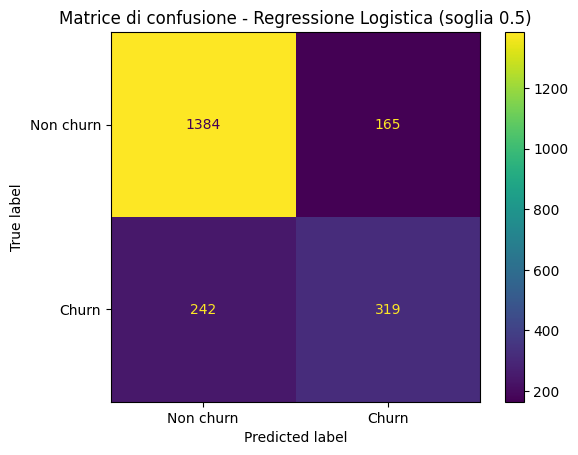

In [92]:
# Applichiamo la soglia 0.5: prob >= soglia -> 1, altrimenti -> 0
threshold = 0.5
pred_test = (predicted_prob >= threshold).astype(int)

# Matrice di confusione
cm_log = confusion_matrix(Y_test, pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=["Non churn", "Churn"])
disp.plot()
plt.title(f"Matrice di confusione - Regressione Logistica (soglia {threshold})")
plt.show()

Dalla matrice di confusione vediamo:
- 1384 veri negativi e 319 veri positivi (classificazioni corrette)
- 165 falsi positivi e 242 falsi negativi (errori)

Il modello è accurato sui clienti che restano, ma individua solo 319 dei 561 churner
reali. I 242 falsi negativi sono l'errore più critico in un problema di churn, e
motivano l'esperimento sulla soglia svolto di seguito.

**Proviamo a cambiare la soglia**

Il dataset è **squilibrato** (73% No, 27% Yes): con la soglia 0.5 il modello tende a privilegiare la classe maggioritaria e a "perdere" diversi clienti che in realtà abbandonano (falsi negativi). Poiché in un problema di churn individuare i clienti a rischio è prioritario, proviamo ad **abbassare la soglia a 0.4**: così classifichiamo come churn anche clienti con probabilità più bassa, individuandone di più, al prezzo di qualche falso positivo in più.

Accuracy (soglia 0.4): 0.785


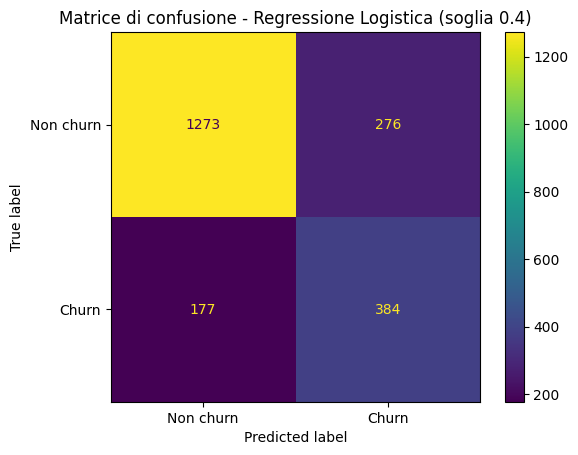

In [93]:
# Abbassiamo la soglia per individuare più churner
threshold = 0.4
pred_test_04 = (predicted_prob >= threshold).astype(int)

acc_04 = accuracy_score(Y_test, pred_test_04)
print(f"Accuracy (soglia {threshold}): {acc_04:.3f}")

cm_04 = confusion_matrix(Y_test, pred_test_04)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_04, display_labels=["Non churn", "Churn"])
disp.plot()
plt.title(f"Matrice di confusione - Regressione Logistica (soglia {threshold})")
plt.show()

L'esperimento conferma il compromesso atteso: l'accuracy scende leggermente (78,5%), ma una soglia più bassa intercetta più
clienti a rischio, a costo di qualche falso allarme in più. In un'ottica di churn,
dove non individuare un cliente che abbandona è l'errore più costoso, questo scambio
è spesso vantaggioso.

La *recall* sulla
classe Churn sale da 0.57 a 0.68 (i veri positivi passano da 319 a 384, i falsi negativi
scendono da 242 a 177): **il modello individua quindi molti più clienti a rischio.**

## Decision Tree

Alleniamo il modello sul training set e generiamo le previsioni sul test set. A differenza della Logistic Regression, è un modello non lineare, capace di catturare relazioni più complesse tra le variabili.

In [94]:
from sklearn import svm, tree
from sklearn.metrics import *

In [95]:
model_dt = tree.DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, Y_train)

DecisionTreeClassifier(random_state=42)

Da notare che non è stato impostato alcun limite di profondità per l'albero (`max_depth`): questo può portare a overfitting sul training set, un aspetto da considerare nell'interpretazione delle metriche successive.

In [96]:
Y_pred2 = model_dt.predict(X_test)
Y_pred2

array([0, 0, 0, ..., 0, 0, 1])

Confrontiamo le predizioni del modello (`Y_pred2`) con i valori reali (`Y_test`), come anticipazione visiva prima del calcolo delle metriche in Fase 4.

In [97]:
pd.DataFrame({'Reale': Y_test.values, 'Predetto': Y_pred2}).head(10)

,Reale,Predetto
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,1,0


Già da questo confronto su un campione ridotto si notano alcune discrepanze tra valori reali e predetti: un'indicazione preliminare che le metriche aggregate (accuracy, precision, recall) saranno necessarie per quantificare la reale capacità predittiva del modello, oltre la singola osservazione visiva.

### Metriche

In [98]:
acc_tree = accuracy_score(Y_test, Y_pred2)
cm_tree = confusion_matrix(Y_test, Y_pred2, labels=[0, 1])
cr_tree = classification_report(Y_test, Y_pred2, target_names=['No Churn', 'Churn'])

print('Accuracy:', acc_tree)
print('\nConfusion Matrix:\n', cm_tree)
print('\nClassification Report:\n', cr_tree)

Accuracy: 0.704739336492891

Confusion Matrix:
 [[1216  333]
 [ 290  271]]

Classification Report:
               precision    recall  f1-score   support

    No Churn       0.81      0.79      0.80      1549
       Churn       0.45      0.48      0.47       561

    accuracy                           0.70      2110
   macro avg       0.63      0.63      0.63      2110
weighted avg       0.71      0.70      0.71      2110



**Confusion matrix**: mostra come le predizioni del Decision Tree si distribuiscono rispetto ai valori reali
* Asse Y (reale): cos'è successo davvero al cliente
* Asse X (predetto): cos'ha previsto il modello



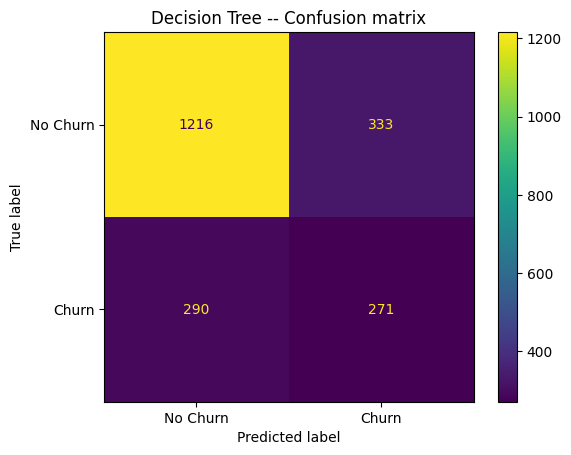

In [99]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=['No Churn', 'Churn']
)
disp.plot()
plt.title("Decision Tree -- Confusion matrix")
plt.show()

Sui 2.110 clienti nel test set, il modello classifica correttamente:
* **1216** (veri negativi) → i clienti che sono effettivamente rimasti, e il modello l'ha previsto correttamente
* **333** (falsi positivi) → i clienti rimasti, ma il modello ha previsto (erroneamente) che avrebbero abbandonato
* **290** (falsi negativi) → i clienti che hanno abbandonato, ma il modello ha previsto (erroneamente) che sarebbero rimasti — questo è l'errore più "costoso" in un problema di churn, perché significa non intervenire su chi rischia davvero di andarsene
* **271** (veri positivi) → i clienti che hanno abbandonato, e il modello l'ha previsto correttamente



L'**accuracy** complessiva è del **70,5%**, ma va interpretata con cautela a causa dello squilibrio di classe. Il classification report lo conferma in modo più dettagliato:
* sulla classe `No Churn` (1.549 clienti): **precision 0,81**, **recall 0,79** — buone prestazioni su entrambi i fronti;
* sulla classe `Churn` (561 clienti): **precision 0,45**, **recall 0,48** — il modello sbaglia più della metà delle volte quando prova a identificare un cliente che abbandona, sia in termini di falsi allarmi (precision bassa) sia di mancate individuazioni (recall bassa).

Il **f1-score** sulla classe `Churn` (0,47) riassume bene questo limite: il Decision Tree fatica a catturare la classe minoritaria, nonostante l'accuracy complessiva sembri accettabile. Il confronto tra accuracy (0,70) e f1-score sulla classe di interesse (0,47) è un punto centrale: l'accuracy da sola sarebbe un indicatore ingannevole delle reali capacità predittive del modello sul problema che interessa di più, cioè identificare chi sta per abbandonare.

## Random Forest

La Random Forest usa **molti alberi decisionali**, introducendo **casualità controllata** per renderli diversi, e **combina le loro decisioni**.

In [100]:
from sklearn.ensemble import RandomForestClassifier

In [101]:
#Addestramento del modello Random Forest
rf = RandomForestClassifier(
    n_estimators=200, #indica il numero di alberi della foresta.
    random_state=42 #rende il risultato riproducibile.
)

rf.fit(X_train, Y_train)

pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(Y_test, pred_rf)

print(f"Accuracy Random Forest: {acc_rf:.3f}")

Accuracy Random Forest: 0.784


Il modello raggiunge un'*accuracy* del **78,4%** sul test set. È un valore realistico e coerente; va però interpretato con cautela, dato lo sbilanciamento del target (~73% "No"): da sola, l'accuracy non basta a giudicare la qualità del modello. Per questo, nella seguente fase, analizzeremo anche *confusion matrix*, *precision* e *recall*.

**Feature Importance**

La feature importance riassume quanto ciascuna variabile ha contribuito alle decisioni della foresta.

In [102]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
})

importance = importance.sort_values("importance", ascending=False)

importance.head(10)

,feature,importance
3,TotalCharges,0.192480
1,tenure,0.168677
2,MonthlyCharges,0.164307
10,InternetService_Fiber optic,0.038230
28,PaymentMethod_Electronic check,0.035314
25,Contract_Two year,0.032032
4,gender_Male,0.028852
13,OnlineSecurity_Yes,0.028119
26,PaperlessBilling_Yes,0.025706
19,TechSupport_Yes,0.023921


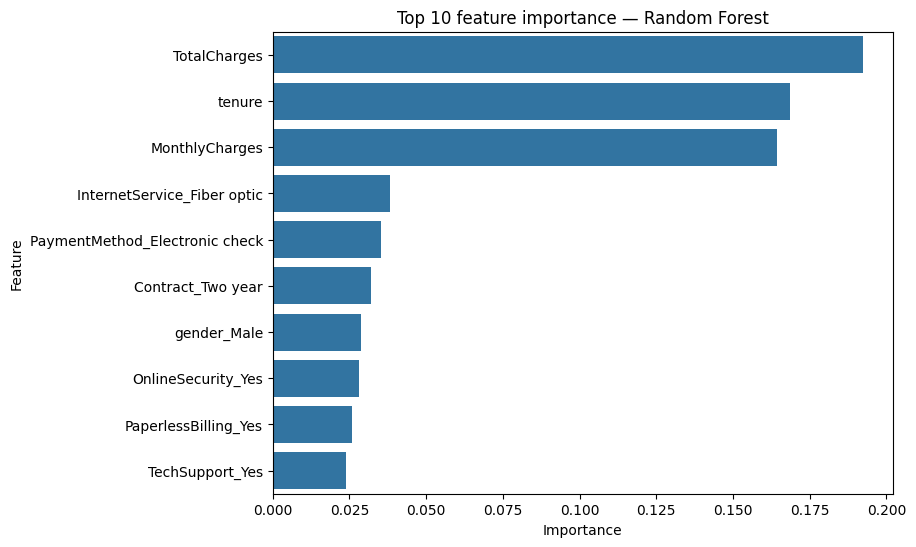

In [103]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance.head(10),
    x="importance",
    y="feature"
)

plt.title("Top 10 feature importance — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

La Random Forest individua come **variabili più influenti** `TotalCharges` (**0,19**), `tenure` (**0,17**) e `MonthlyCharges` (**0,16**), seguite a distanza da `InternetService_Fiber optic`, `PaymentMethod_Electronic check `e dal `tipo di contratto`. Il risultato è del tutto coerente con l'analisi esplorativa: anzianità, spesa e tipo di contratto erano già emerse come fortemente associate all'abbandono. Va ricordato che TotalCharges, tenure e MonthlyCharges sono tra loro correlate (ridondanza vista nella heatmap), quindi la loro importanza è in parte condivisa.

Aggiungiamo una variabiale casuale per vedere se la RF le assegna un'importanza bassa.

In [104]:
X_noise = X.copy()
X_noise["random_noise"] = np.random.normal(0, 1, len(X_noise))

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_noise,
    Y,
    test_size=0.30,
    random_state=42,
    stratify=Y
)

rf_noise = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_noise.fit(X_train_n, y_train_n)

importance_noise = pd.DataFrame({
    "feature": X_noise.columns,
    "importance": rf_noise.feature_importances_
}).sort_values("importance", ascending=False)

importance_noise.head(10)

,feature,importance
3,TotalCharges,0.161328
1,tenure,0.152900
2,MonthlyCharges,0.135636
30,random_noise,0.120874
10,InternetService_Fiber optic,0.039988
28,PaymentMethod_Electronic check,0.032216
25,Contract_Two year,0.030041
13,OnlineSecurity_Yes,0.025213
4,gender_Male,0.024123
19,TechSupport_Yes,0.023037


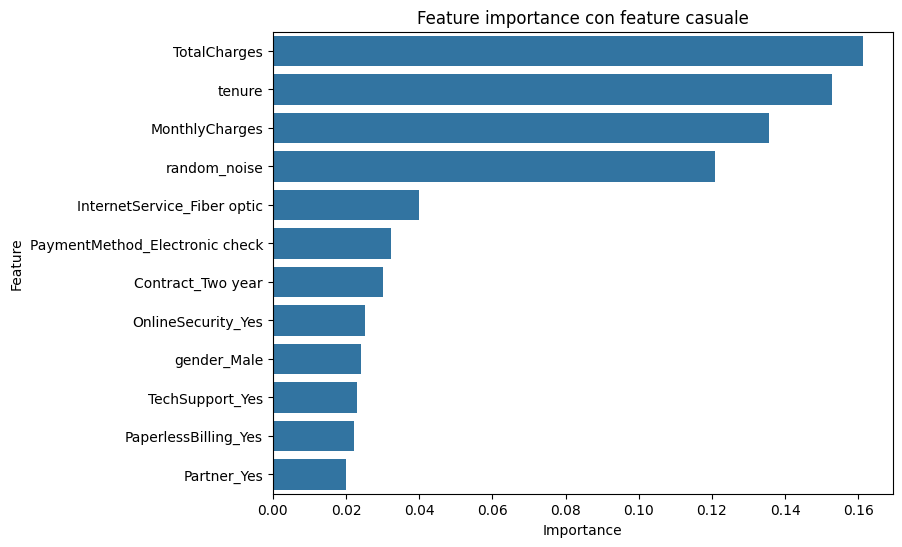

In [105]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance_noise.head(12),
    x="importance",
    y="feature"
)

plt.title("Feature importance con feature casuale")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

Come controllo di robustezza abbiamo aggiunto una variabile puramente casuale (`random_noise`) e osservato l'importanza attribuita dalla Random Forest. Contrariamente alle attese, il rumore riceve un'importanza elevata (**0,12**), collocandosi in quarta posizione. Questo risultato non indica che il rumore sia informativo, ma evidenzia un *limite* noto della feature importance: essa tende a sovrastimare l'importanza delle variabili continue (come il rumore), che offrono molti più punti di split, rispetto alle variabili binarie.

### Metriche

**Matrice di confusione - RF**

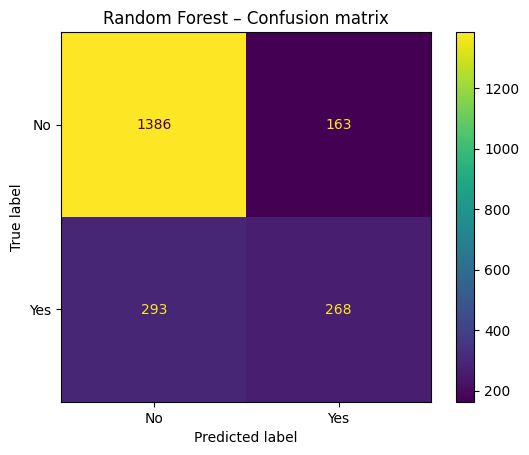

In [106]:
cm_rf = confusion_matrix(Y_test, pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No", "Yes"]
)

disp.plot()
plt.title("Random Forest – Confusion matrix")
plt.show()

 La matrice mostra come si distribuiscono le previsioni. Il modello riconosce molto bene i clienti che restano (classe "No"), mentre commette più errori sui clienti che abbandonano: una quota rilevante di churner reali viene classificata erroneamente come "No". Questo comportamento è tipico nei dataset sbilanciati, dove il modello tende a favorire la classe più numerosa.

**Classification report - RF**

In [107]:
print(classification_report(
    Y_test,
    pred_rf,
    target_names=["No", "Yes"]
))

              precision    recall  f1-score   support

          No       0.83      0.89      0.86      1549
         Yes       0.62      0.48      0.54       561

    accuracy                           0.78      2110
   macro avg       0.72      0.69      0.70      2110
weighted avg       0.77      0.78      0.77      2110



Il report evidenzia il vero limite del modello. Sulla classe "No" le prestazioni sono buone (precision **0,83**, recall **0,89**). Sulla classe "Yes", invece, precision e recall calano sensibilmente (**0,62** e **0,48**): in particolare il recall di 0,48 indica che **il modello individua meno della metà dei clienti che effettivamente abbandonano**. In un contesto applicativo di prevenzione del churn questo è il dato più critico, perché significa che oltre la metà dei clienti a rischio non verrebbe intercettata. L'F1-score della classe "Yes" (**0,54**) sintetizza questo squilibrio. Il risultato è una conseguenza dello sbilanciamento osservato nella fase descrittiva.



---
**Modellazione con Variabili Selezionate**





In [108]:
# Variabili selezionate come più importanti
feature_importanti = [
    "TotalCharges",
    "tenure",
    "MonthlyCharges",
    "InternetService_Fiber optic",
    "PaymentMethod_Electronic check",
    "Contract_Two year",
]

# Sottoinsieme di train e test con sole queste colonne
X_train_sel = X_train[feature_importanti]
X_test_sel = X_test[feature_importanti]



---


Nella sezione successiva ripeteremo le stesse valutazioni utilizzando solo le feature selezionate tramite le importanze della Random Forest, per verificare se la riduzione di dimensionalità migliora le capacità del modello di identificare la classe `Churn`.

## Regressione Logistica con Variabili Selezionate

In [109]:
# Nuovo modello addestrato solo su queste feature
log_model_sel = LogisticRegression(max_iter=3000)
log_model_sel.fit(X_train_sel, Y_train)


LogisticRegression(max_iter=3000)

### Metriche


In [110]:

# Accuracy
pred_log_sel = log_model_sel.predict(X_test_sel)
acc_log_sel = accuracy_score(Y_test, pred_log_sel)
print(f"Accuracy modello con variabili selezionate: {acc_log_sel:.3f}")

Accuracy modello con variabili selezionate: 0.792


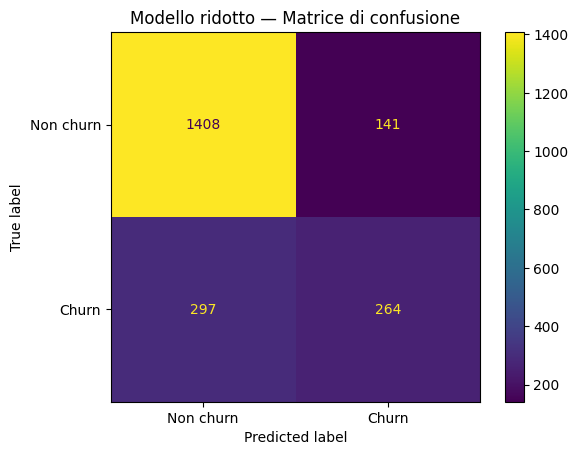

In [111]:
# Matrice di confusione
cm_log_sel = confusion_matrix(Y_test, pred_log_sel, labels=[0, 1])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_log_sel,
    display_labels=["Non churn", "Churn"]
)
disp.plot()
plt.title("Modello ridotto — Matrice di confusione")
plt.show()

In [112]:
# Metriche complete (precision, recall, f1-score per classe)
cr_log_sel = classification_report(Y_test, pred_log_sel, target_names=["No Churn", "Churn"])
print("Classification Report:\n", cr_log_sel)

Classification Report:
               precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1549
       Churn       0.65      0.47      0.55       561

    accuracy                           0.79      2110
   macro avg       0.74      0.69      0.71      2110
weighted avg       0.78      0.79      0.78      2110



Il modello completo raggiunge un'accuracy di 0.81, quello ridotto a sole 6 variabili di 0.79: appena 2 punti di differenza. **Quelle poche variabili catturano quindi quasi tutto il segnale predittivo**  a conferma di quanto indicato dalla feature importance.

Tuttavia il confronto sulla sola accuracy è ingannevole, perché il dataset è sbilanciato
(~73% Non churn). Guardando le metriche per classe, il modello ridotto è ottimo sui Non
churn (f1 0.87, recall 0.91) ma debole sui Churn (f1 0.55, recall 0.47). Rispetto al modello
completo, proprio la recall sulla classe Churn è la metrica che peggiora di più: scende da
0.57 a 0.47.

Rimuovendo metà delle variabili il modello propende ancora di più verso la classe maggioritaria, diventando **meno capace a individuare i clienti che abbandonano**.
Per questo, in un problema di churn, conviene
valutare i modelli sulla recall della classe Churn più che sull'accuracy: una recall di 0.47
significa che **più della metà dei churner reali passa inosservata.**

## Decision Tree con variabili selezionate

In [113]:
from sklearn import tree
model_dt = tree.DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train_sel, Y_train)

DecisionTreeClassifier(random_state=42)

In [114]:
Y_pred3 = model_dt.predict(X_test_sel)
Y_pred3

array([0, 0, 0, ..., 0, 0, 0])

Generiamo le previsioni con il modello allenato sulle variabili selezionate, da confrontare poi con i valori reali.

In [116]:
pd.DataFrame({'Reale': Y_test.values, 'Predetto': Y_pred3}).head(10)

,Reale,Predetto
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,1,0


In [117]:
acc_tree_sel = accuracy_score(Y_test, Y_pred3)
cm_tree_sel = confusion_matrix(Y_test, Y_pred3, labels=[0, 1])
cr_tree_sel = classification_report(Y_test, Y_pred3, target_names=['No Churn', 'Churn'])

print('Accuracy:', acc_tree_sel)
print('\nConfusion Matrix:\n', cm_tree_sel)
print('\nClassification Report:\n', cr_tree_sel)

Accuracy: 0.7090047393364929

Confusion Matrix:
 [[1235  314]
 [ 300  261]]

Classification Report:
               precision    recall  f1-score   support

    No Churn       0.80      0.80      0.80      1549
       Churn       0.45      0.47      0.46       561

    accuracy                           0.71      2110
   macro avg       0.63      0.63      0.63      2110
weighted avg       0.71      0.71      0.71      2110



Il modello addestrato sulle 6 variabili più importanti raggiunge un'**accuracy** del **71,0%** (1.496 previsioni corrette su 2.110), valore ancora inferiore al baseline naive (73,46%, la quota di clienti `No Churn` nel test set). Anche con un sottoinsieme ridotto di variabili, quindi, l'accuracy resta una metrica poco informativa data la natura sbilanciata del problema: è la **recall** sulla classe Churn a fornire l'informazione più rilevante.

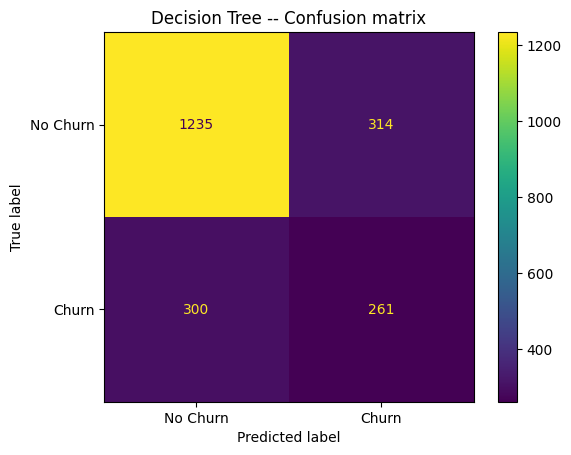

In [130]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree_sel,
    display_labels=['No Churn', 'Churn']
)

disp.plot()
plt.title("Decision Tree -- Confusion matrix")
plt.show()

Dalla **matrice di confusione** emergono 1.235 veri negativi, 314 falsi positivi, 300 falsi negativi e 261 veri positivi. Il modello identifica correttamente 261 clienti su 561 che hanno effettivamente abbandonato il servizio, con una recall sulla classe `Churn` di **0,47** (precision 0,45, f1-score 0,46); sulla classe `No Churn` precision, recall e f1-score sono tutti pari a **0,80**.



Rispetto al modello allenato su tutte le variabili (**accuracy** **70,5%**, recall sulla classe Churn 0,48), la riduzione a 6 feature porta a un'**accuracy** leggermente superiore (**71,0%**) e a una recall praticamente equivalente (0,47) sulla classe minoritaria, segno che le variabili selezionate catturano la maggior parte del segnale predittivo utile a riconoscere i clienti a rischio churn, con il vantaggio aggiuntivo di un modello più semplice e interpretabile.

## Random Forest con variabili selezionate

In [119]:
from sklearn.ensemble import RandomForestClassifier
rf_sel = RandomForestClassifier(
    n_estimators=200,    # numero di alberi della foresta
    random_state=42      # rende il risultato riproducibile
)
rf_sel.fit(X_train_sel, Y_train)

pred_rf_sel = rf_sel.predict(X_test_sel)
acc_rf_sel = accuracy_score(Y_test, pred_rf_sel)
print(f"Accuracy Random Forest (modello ridotto): {acc_rf_sel:.3f}")

Accuracy Random Forest (modello ridotto): 0.771


### Metriche

**Classification report - RF selei**

In [120]:
print(classification_report(Y_test, pred_rf_sel, target_names=["No", "Yes"]))

              precision    recall  f1-score   support

          No       0.82      0.88      0.85      1549
         Yes       0.59      0.48      0.53       561

    accuracy                           0.77      2110
   macro avg       0.70      0.68      0.69      2110
weighted avg       0.76      0.77      0.76      2110



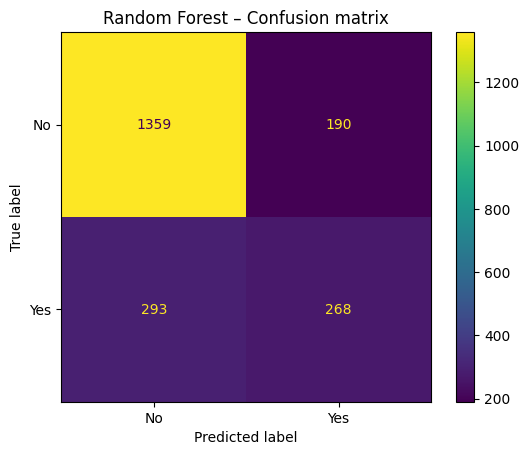

In [121]:
cm_rf_sel = confusion_matrix(Y_test, pred_rf_sel)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_sel,
    display_labels=["No", "Yes"]
)

disp.plot()
plt.title("Random Forest – Confusion matrix")
plt.show()

# Fase 4: Valutazione e Interpretazione dei risultati - Modelli a confronto

In [122]:
# Confronto delle accuracy dei tre modelli con tutte le variabili
comparison = pd.DataFrame({
    "model": ["Regressione logistica", "Decision Tree", "Random Forest"],
    "accuracy": [acc_log, acc_tree, acc_rf]
})
comparison

,model,accuracy
0,Regressione logistica,0.807109
1,Decision Tree,0.704739
2,Random Forest,0.783886


Confrontando l'accuracy dei tre modelli allenati su tutte le variabili, la **Regressione logistica** ottiene il valore più alto (**80,7%**), seguita dalla **Random Forest** (**78,4%**) e infine dal **Decision Tree** (**70,5%**), che risulta l'unico modello sotto il baseline naive (73,46%, la quota di clienti `No Churn`). Questo primo confronto va però letto con cautela: l'accuracy non distingue come ciascun modello si comporta sulla classe minoritaria `Churn`, che è l'obiettivo principale del problema.

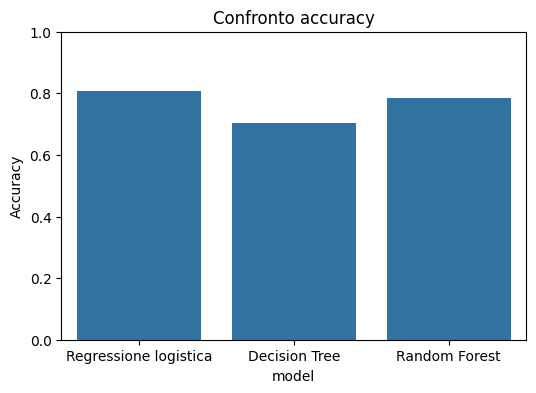

In [123]:
plt.figure(figsize=(6,4))
sns.barplot(data=comparison, x="model", y="accuracy")
plt.ylim(0, 1)
plt.title("Confronto accuracy")
plt.ylabel("Accuracy")
plt.show()

Il grafico evidenzia visivamente il distacco del **Decision Tree** rispetto agli altri due modelli, mentre **Regressione logistica** e **Random Forest** mostrano accuracy più vicine tra loro. Tuttavia, dato lo squilibrio di classe osservato in Fase 2, un'accuracy alta non garantisce una buona capacità di identificare i clienti a rischio di abbandono: per questo motivo confrontiamo anche precision, recall e f1-score sulla classe `Churn`.

In [124]:
report_log  = classification_report(Y_test, pred_log,  output_dict=True)
report_tree = classification_report(Y_test, Y_pred2, output_dict=True)
report_rf   = classification_report(Y_test, pred_rf,   output_dict=True)

prec_log = report_log["1"]["precision"];  rec_log = report_log["1"]["recall"];  f1_log = report_log["1"]["f1-score"]
prec_tree = report_tree["1"]["precision"]; rec_tree = report_tree["1"]["recall"]; f1_tree = report_tree["1"]["f1-score"]
prec_rf = report_rf["1"]["precision"];    rec_rf = report_rf["1"]["recall"];    f1_rf = report_rf["1"]["f1-score"]

In [125]:
# Confronto metriche Classification Report dei modelli con tutte le variabili
comparison_cf = pd.DataFrame({
    "model": ["Regressione logistica", "Decision Tree", "Random Forest"],
    "precision_Yes": [prec_log, prec_tree, prec_rf],
    "recall_Yes": [rec_log, rec_tree, rec_rf],
    "f1_Yes": [f1_log, f1_tree, f1_rf]
})
comparison_cf

,model,precision_Yes,recall_Yes,f1_Yes
0,Regressione logistica,0.659091,0.568627,0.610526
1,Decision Tree,0.448675,0.483066,0.465236
2,Random Forest,0.621810,0.477718,0.540323


Il confronto sulla classe `Churn` cambia in parte la lettura data dall'accuracy. La **Regressione logistica** ottiene le prestazioni migliori su tutti i fronti (precision **0,66**, recall **0,57**, f1-score **0,61**), mentre la **Random Forest**, pur avendo un'accuracy complessiva superiore al Decision Tree, mostra una recall sulla classe `Churn` (**0,48**) praticamente identica a quella del Decision Tree (**0,48**), compensata però da una precision più alta (**0,62** contro **0,45**) e quindi da un f1-score migliore (**0,54** contro **0,47**).

In sintesi, la **Regressione logistica** risulta il modello più equilibrato per questo problema: non solo ha l'accuracy più alta, ma è anche quella che identifica la quota maggiore di clienti a rischio di abbandono (recall 0,57), aspetto centrale in un problema di churn dove il costo di un falso negativo è elevato. Questo risultato è in parte controintuitivo, dato che modelli più complessi come la Random Forest non garantiscono automaticamente prestazioni migliori sulla classe di interesse.

In [126]:
# Confronto delle accuracy dei tre modelli con le variabili selezionate
comparison_sel = pd.DataFrame({
    "model": ["Regressione logistica", "Decision Tree", "Random Forest"],
    "accuracy": [acc_log_sel, acc_tree_sel, acc_rf_sel]
})
comparison_sel

,model,accuracy
0,Regressione logistica,0.792417
1,Decision Tree,0.709005
2,Random Forest,0.771090


Anche con le variabili selezionate l'ordinamento tra i modelli resta lo stesso visto con tutte le feature: **Regressione logistica** in testa (**79,2%**), seguita da **Random Forest** (**77,1%**) e **Decision Tree** (**70,9%**), ancora sotto il baseline naive (73,46%). Rispetto alla versione con tutte le variabili, l'accuracy scende leggermente per Regressione logistica (80,7% → 79,2%) e Random Forest (78,4% → 77,1%), mentre resta praticamente invariata per il Decision Tree (70,5% → 70,9%).

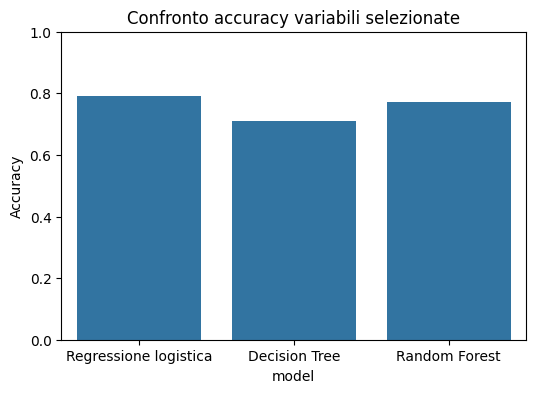

In [127]:
plt.figure(figsize=(6,4))
sns.barplot(data=comparison_sel, x="model", y="accuracy")
plt.ylim(0, 1)
plt.title("Confronto accuracy variabili selezionate")
plt.ylabel("Accuracy")
plt.show()

Il grafico mostra lo stesso pattern già osservato con tutte le variabili: Regressione logistica e Random Forest si mantengono vicine tra loro e ben distanziate dal Decision Tree. La riduzione a 6 feature non cambia quindi l'ordinamento dei modelli sull'accuracy, ma — come visto in precedenza — questa metrica da sola non è sufficiente a valutare le prestazioni sulla classe `Churn`.

In [128]:
report_log_sel  = classification_report(Y_test, pred_log_sel,  output_dict=True)
report_tree_sel = classification_report(Y_test, Y_pred3, output_dict=True)
report_rf_sel   = classification_report(Y_test, pred_rf_sel,   output_dict=True)

prec_log_sel = report_log_sel["1"]["precision"];  rec_log_sel = report_log_sel["1"]["recall"];  f1_log_sel = report_log_sel["1"]["f1-score"]
prec_tree_sel = report_tree_sel["1"]["precision"]; rec_tree_sel = report_tree_sel["1"]["recall"]; f1_tree_sel = report_tree_sel["1"]["f1-score"]
prec_rf_sel = report_rf_sel["1"]["precision"];    rec_rf_sel = report_rf_sel["1"]["recall"];    f1_rf_sel = report_rf_sel["1"]["f1-score"]

In [129]:
# Confronto metriche Classification Report dei modelli con le variabili selezionate
comparison_cf_sel = pd.DataFrame({
    "model": ["Regressione logistica", "Decision Tree", "Random Forest"],
    "precision_Yes": [prec_log_sel, prec_tree_sel, prec_rf_sel],
    "recall_Yes": [rec_log_sel, rec_tree_sel, rec_rf_sel],
    "f1_Yes": [f1_log_sel, f1_tree_sel, f1_rf_sel]
})
comparison_cf_sel

,model,precision_Yes,recall_Yes,f1_Yes
0,Regressione logistica,0.651852,0.470588,0.546584
1,Decision Tree,0.453913,0.465241,0.459507
2,Random Forest,0.585153,0.477718,0.526006


Il confronto sulla classe `Churn` rivela un aspetto importante che l'accuracy da sola non mostrava: la riduzione a 6 feature **non** ha lo stesso impatto su tutti i modelli. La **Random Forest** mantiene una recall sulla classe `Churn` praticamente identica (**0,48** con tutte le feature, **0,48** con quelle selezionate) e una precision solo leggermente inferiore (0,62 → 0,59), confermando che le 6 variabili catturano gran parte del segnale utile per questo modello. Il **Decision Tree** mostra un calo lieve di recall (0,48 → 0,47) ma f1-score quasi invariato (0,47 → 0,46).

La **Regressione logistica**, invece, è il modello che paga il prezzo più alto: la recall sulla classe `Churn` scende da **0,57** a **0,47**, un calo non trascurabile proprio sulla metrica più rilevante per il problema. Questo significa che, sebbene la regressione logistica resti il modello con l'accuracy più alta anche con le feature selezionate, la riduzione di dimensionalità ha un costo concreto in termini di clienti a rischio non identificati. In sintesi: la feature selection funziona bene per la Random Forest, in modo neutro per il Decision Tree, ma penalizza la Regressione logistica più degli altri due modelli — un'osservazione che vale la pena evidenziare nelle conclusioni finali del progetto, perché smentisce l'idea che "meno variabili" sia sempre un vantaggio univoco per tutti i modelli.